In [1]:

import pandas as pd

df = pd.read_csv("/Users/aman/Downloads/IMDB Dataset.csv")


print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())


df.head()


Shape of dataset: (50000, 2)

Columns: ['review', 'sentiment']

Data types:
 review       object
sentiment    object
dtype: object

Missing values:
 review       0
sentiment    0
dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [2]:
# CELL 1 — LOAD & BASIC AUDIT
import numpy as np
import pandas as pd

# Structure & types
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)

# Label hygiene (view-only; not overwriting original)
labels_norm = df['sentiment'].astype(str).str.strip().str.lower()
print("\nUnique labels (normalized):", sorted(labels_norm.unique()))

# Missing values
print("\nMissing values:\n", df.isna().sum())

# Quick peek
display(df.head(3))


Shape: (50000, 2)
Columns: ['review', 'sentiment']

Dtypes:
 review       object
sentiment    object
dtype: object

Unique labels (normalized): ['negative', 'positive']

Missing values:
 review       0
sentiment    0
dtype: int64


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


In [3]:
# CELL 2 — QUALITY DIAGNOSTICS 
import re

# --- Duplicate checks ---

n_exact_dups = df.duplicated(subset=['review']).sum()
print("Exact duplicate reviews:", n_exact_dups)

# normalized duplicates (strip simple HTML/whitespace, lowercase)
HTML_TAG_RE = re.compile(r'<[^>]+>')
WS_RE       = re.compile(r'\s+')

def _rough_norm(x: str) -> str:
    x = HTML_TAG_RE.sub(' ', x)      # strip simple HTML tags
    x = WS_RE.sub(' ', x)            # collapse whitespace
    return x.strip().lower()

rough = df['review'].map(_rough_norm)
n_rough_dups = rough.duplicated().sum()
print("Rough normalized duplicates:", n_rough_dups)

# --- Artifact prevalence (counts only) ---
has_html    = df['review'].str.contains(HTML_TAG_RE)
NON_ASCII_RE = re.compile(r'[^\x00-\x7F]')
has_nonasc  = df['review'].str.contains(NON_ASCII_RE)

print(f"Rows with HTML-like tags: {has_html.sum()} ({has_html.mean():.1%})")
print(f"Rows with non-ASCII     : {has_nonasc.sum()} ({has_nonasc.mean():.1%})")

# --- Length stats (characters & simple tokens) ---
df['_char_len'] = df['review'].str.len()
df['_tok_len']  = df['review'].str.split().map(len)

summary = pd.DataFrame({
    'char_len': df['_char_len'].describe(percentiles=[.5,.9,.95,.99]),
    'tok_len' : df['_tok_len'].describe(percentiles=[.5,.9,.95,.99])
})
print("\nLength summary (chars & tokens):")
display(summary)

# Handy percentiles (to help pick max sequence length later)
p90 = np.percentile(df['_tok_len'], 90)
p95 = np.percentile(df['_tok_len'], 95)
print(f"Token length p90 ≈ {int(p90)}, p95 ≈ {int(p95)}")


Exact duplicate reviews: 418
Rough normalized duplicates: 422
Rows with HTML-like tags: 29202 (58.4%)
Rows with non-ASCII     : 4660 (9.3%)

Length summary (chars & tokens):


,char_len,tok_len
count,50000.000000,50000.000000
mean,1309.431020,231.156940
std,989.728014,171.343997
min,32.000000,4.000000
50%,970.000000,173.000000
90%,2581.000000,451.000000
95%,3391.000000,590.000000
99%,5179.010000,908.000000
max,13704.000000,2470.000000


Token length p90 ≈ 451, p95 ≈ 590


In [4]:
# CELL 3 — GLANCE AT A FEW RAW ROWS
import numpy as np
import re

HTML_RE      = re.compile(r'<[^>]+>')
NON_ASCII_RE = re.compile(r'[^\x00-\x7F]')

print("\nSample raw reviews (showing HTML/non-ASCII presence if any):")
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(df), size=3, replace=False)

for i in sample_idx:
    txt = df.loc[i, 'review']
    has_html_row    = bool(HTML_RE.search(txt))
    has_nonascii_row= bool(NON_ASCII_RE.search(txt))  # or: any(ord(c) > 127 for c in txt)
    print("\n--- Row {} | HTML:{} | nonASCII:{} ---".format(i, has_html_row, has_nonascii_row))
    print(txt[:500])



Sample raw reviews (showing HTML/non-ASCII presence if any):

--- Row 33553 | HTML:False | nonASCII:False ---
I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok to have a huge fat man vs a strong man but I'm glad times have changed. It was a terrible main event just like every match Luger is in is terrible. Other matches on the card were Razor Ramon vs Ted Di

--- Row 9427 | HTML:True | nonASCII:False ---
Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fans both Male and Female in as many different countries as you can think of that just adore this T.V miniseries. It has elements that can be found in almost every other show on T.V, character driven drama t

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


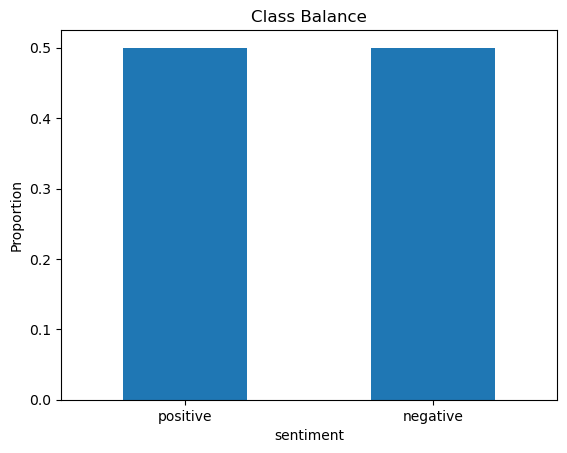

In [5]:
#UNIVARIATE
import matplotlib.pyplot as plt

lbl_counts = df['sentiment'].str.lower().value_counts()
print(lbl_counts)
(lbl_counts / lbl_counts.sum()).plot(kind='bar', title='Class Balance', rot=0)
plt.ylabel('Proportion'); plt.show()


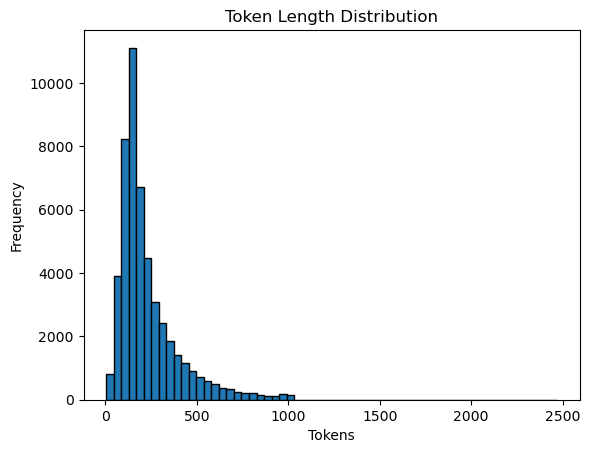

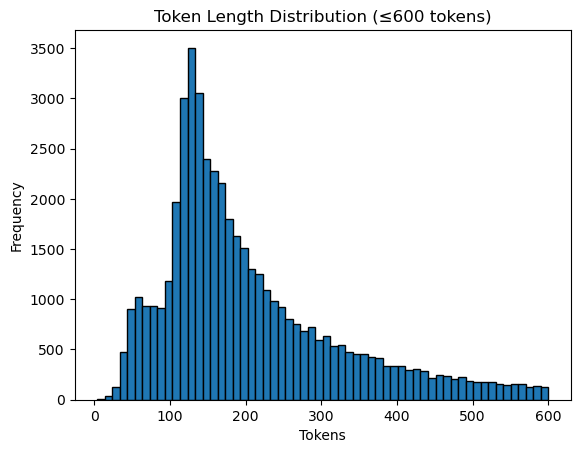

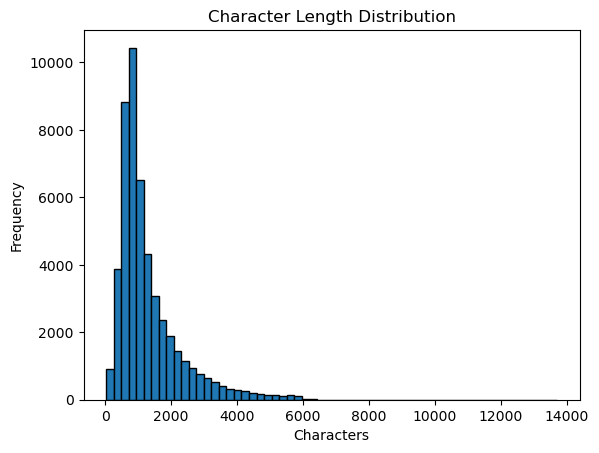

In [6]:
fig, ax = plt.subplots()
df['_tok_len'].plot(kind='hist', bins=60, edgecolor='black', ax=ax, title='Token Length Distribution')
ax.set_xlabel('Tokens'); plt.show()

fig, ax = plt.subplots()
df.loc[df['_tok_len']<=600, '_tok_len'].plot(kind='hist', bins=60, edgecolor='black', ax=ax,
                                             title='Token Length Distribution (≤600 tokens)')
ax.set_xlabel('Tokens'); plt.show()

fig, ax = plt.subplots()
df['_char_len'].plot(kind='hist', bins=60, edgecolor='black', ax=ax, title='Character Length Distribution')
ax.set_xlabel('Characters'); plt.show()


{'has_html': 29202, 'non_ascii': 4660}


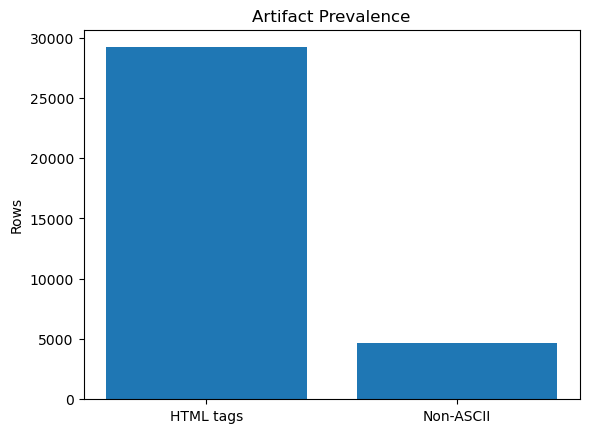

In [7]:
artifact_counts = {
    'has_html'   : int((df['review'].str.contains(r'<[^>]+>')).sum()),
    'non_ascii'  : int((df['review'].str.contains(r'[^\x00-\x7F]')).sum())
}
print(artifact_counts)

plt.bar(['HTML tags', 'Non-ASCII'], [artifact_counts['has_html'], artifact_counts['non_ascii']])
plt.title('Artifact Prevalence'); plt.ylabel('Rows'); plt.show()


In [8]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

def top_ngrams(texts, n=20, ngram_range=(1,2)):
    vec = TfidfVectorizer(ngram_range=ngram_range, min_df=5, max_df=0.9)
    X   = vec.fit_transform(texts)
    means = np.asarray(X.mean(axis=0)).ravel()
    vocab = np.array(vec.get_feature_names_out())
    top_idx = means.argsort()[::-1][:n]
    return list(zip(vocab[top_idx], means[top_idx]))

pos_top = top_ngrams(df.loc[df['sentiment'].str.lower()=='positive', 'review'], n=25, ngram_range=(1,2))
neg_top = top_ngrams(df.loc[df['sentiment'].str.lower()=='negative', 'review'], n=25, ngram_range=(1,2))

print("\nTop n-grams — POSITIVE:\n", pos_top)
print("\nTop n-grams — NEGATIVE:\n", neg_top)



Top n-grams — POSITIVE:
 [('br', 0.05030769231284624), ('it', 0.03955594241193663), ('in', 0.03674760972259283), ('this', 0.02983624943765962), ('that', 0.028621324053474197), ('br br', 0.02517813984559319), ('movie', 0.024222601162662147), ('was', 0.023517657981155626), ('as', 0.02344609849517713), ('film', 0.023282394920569775), ('you', 0.020831737623761924), ('with', 0.02047450412208352), ('for', 0.020231380737314026), ('of the', 0.019686238334950895), ('but', 0.0191149803090102), ('his', 0.018228982565604766), ('he', 0.01782362146835388), ('on', 0.016846648451925548), ('are', 0.01585226716128616), ('not', 0.015349599198871322), ('one', 0.014987761132422443), ('have', 0.014303839793945134), ('be', 0.013820543886170388), ('her', 0.013797290937736363), ('in the', 0.01378843166808449)]

Top n-grams — NEGATIVE:
 [('br', 0.05409543865896527), ('is', 0.039764662167989476), ('it', 0.03942384403770443), ('in', 0.0340181457334808), ('that', 0.030639519030323786), ('movie', 0.028023886952100

             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  229.46456  164.947795   4.0  128.0  174.0  278.0  1522.0
positive   25000.0  232.84932  177.497046  10.0  125.0  172.0  284.0  2470.0


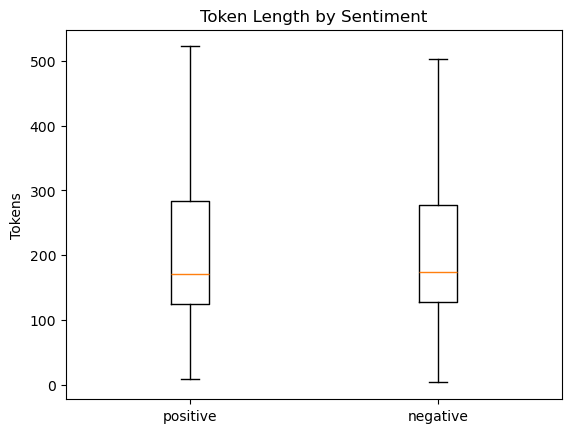

Cohen’s d (length vs label): 0.020


In [9]:
#BIVARIATE
# Summary stats per class
by_len = df.groupby(df['sentiment'].str.lower())['_tok_len'].describe()
print(by_len)

# Boxplots with matplotlib (no seaborn required)
data_pos = df.loc[df['sentiment'].str.lower()=='positive', '_tok_len']
data_neg = df.loc[df['sentiment'].str.lower()=='negative', '_tok_len']

plt.boxplot([data_pos, data_neg], labels=['positive','negative'], showfliers=False)
plt.title('Token Length by Sentiment'); plt.ylabel('Tokens'); plt.show()

# Simple effect size (Cohen’s d)
import math
m1, m2 = data_pos.mean(), data_neg.mean()
v1, v2 = data_pos.var(ddof=1), data_neg.var(ddof=1)
d = (m1 - m2) / math.sqrt(0.5*(v1+v2))
print(f"Cohen’s d (length vs label): {d:.3f}")


             count     mean       std  min  25%  50%  75%   max
sentiment                                                      
negative   25000.0  3.77724  3.314220  0.0  2.0  3.0  5.0  40.0
positive   25000.0  2.72260  2.792025  0.0  1.0  2.0  4.0  31.0


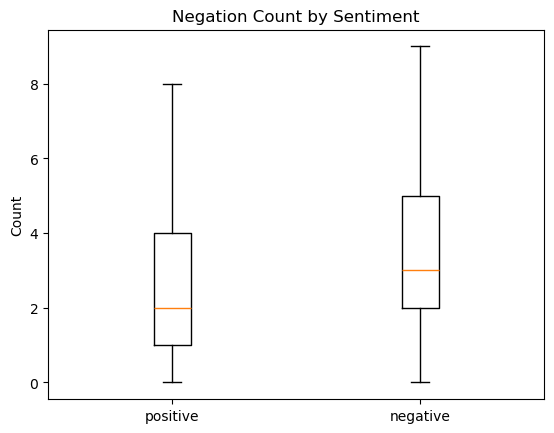

In [10]:
NEG_WORDS = r'\b(no|not|never|none|nothing|nowhere|neither|nor|cannot|can\'t|don\'t|didn\'t|won\'t|shouldn\'t|isn\'t|wasn\'t|weren\'t|ain\'t)\b'
df['_neg_cnt'] = df['review'].str.lower().str.count(NEG_WORDS)

neg_summary = df.groupby(df['sentiment'].str.lower())['_neg_cnt'].describe()
print(neg_summary)

plt.boxplot([
    df.loc[df['sentiment'].str.lower()=='positive','_neg_cnt'],
    df.loc[df['sentiment'].str.lower()=='negative','_neg_cnt']],
    labels=['positive','negative'], showfliers=False)
plt.title('Negation Count by Sentiment'); plt.ylabel('Count'); plt.show()


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

vec = TfidfVectorizer(ngram_range=(1,2), min_df=5, max_df=0.95)
X   = vec.fit_transform(df['review'])
y   = (df['sentiment'].str.lower()=='positive').astype(int).values

chi2_vals, p_vals = chi2(X, y)
feat = np.array(vec.get_feature_names_out())

# Most associated with positive / negative
top_pos = feat[np.argsort(chi2_vals)][-30:][::-1]
top_neg = feat[np.argsort(chi2_vals)[:30]]

print("\nMost discriminative (positive):\n", top_pos)
print("\nMost discriminative (negative):\n", top_neg)



Most discriminative (positive):
 ['bad' 'worst' 'the worst' 'waste' 'awful' 'great' 'terrible' 'excellent'
 'horrible' 'boring' 'stupid' 'waste of' 'worse' 'wonderful' 'poor'
 'so bad' 'crap' 'nothing' 'no' 'minutes' 'worst movie' 'poorly' 'love'
 'the best' 'best' 'lame' 'is great' 'avoid' 'amazing' 'loved']

Most discriminative (negative):
 ['life hope' 'made difference' 'to 1960' 'memory this' 'savage is'
 'im glad' 'well dressed' 'first 50' 'apes is' 'was scary' 'on tokyo'
 'john madden' 'original actor' 'channel but' 'stalled' 'here although'
 'to divert' 'attraction that' 'times people' 'commercial or' 'guests and'
 'wild eyed' 'publicised' 'than face' 'great horror' 'who bear'
 'exploratory' 'with rifles' 'understanding how' 'hand gestures']


In [12]:
# Directional discriminative n-grams for POS vs NEG (fixed)
import re, numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1) Temporary cleaned copy for vectorization 
HTML_TAG_RE = re.compile(r'<[^>]+>')
def clean_html(s: str) -> str:
    s = HTML_TAG_RE.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

text_clean = df['review'].map(clean_html)
y = (df['sentiment'].str.lower()=='positive').astype(int).values

# 2) TF-IDF with a token pattern that keeps contractions ("don't") and basic punctuation signal
vec = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=5,
    max_df=0.95,
    token_pattern=r"[A-Za-z0-9]+'[A-Za-z0-9]+|[A-Za-z0-9]+|[!?]{1,3}"
)
X = vec.fit_transform(text_clean)
feat = np.array(vec.get_feature_names_out())

# 3) Class-conditional means and directional ranking
pos_mean = X[y==1].mean(axis=0).A1
neg_mean = X[y==0].mean(axis=0).A1

pos_gain = pos_mean - neg_mean   # higher => more positive
neg_gain = neg_mean - pos_mean   # higher => more negative

# Optional: drop trivial artifacts (like 'br')
mask_keep = ~np.isin(feat, ['br','br br'])
feat_f = feat[mask_keep]
pos_gain_f = pos_gain[mask_keep]
neg_gain_f = neg_gain[mask_keep]

top_pos_idx = np.argsort(pos_gain_f)[-30:][::-1]
top_neg_idx = np.argsort(neg_gain_f)[-30:][::-1]

print("\nMost discriminative for POSITIVE:")
print(list(zip(feat_f[top_pos_idx], pos_gain_f[top_pos_idx])))

print("\nMost discriminative for NEGATIVE:")
print(list(zip(feat_f[top_neg_idx], neg_gain_f[top_neg_idx])))



Most discriminative for POSITIVE:
[('great', 0.007236062153136645), ('his', 0.0046140810023491425), ('love', 0.004359702586091059), ('best', 0.004219790275361119), ('as', 0.0038667469659655826), ('excellent', 0.003711921907857076), ('is a', 0.0035785207551420027), ('a great', 0.0035179603859560402), ('is', 0.0034969109228067813), ('the best', 0.0034886214971176065), ('very', 0.003416184441725407), ('of', 0.003366244682068101), ('well', 0.003312829715952396), ('wonderful', 0.0031156410075960494), ('in', 0.003041516539834789), ('also', 0.002740068285621731), ('life', 0.002689688590203563), ('one of', 0.002468891670312401), ('loved', 0.0024573999704685994), ('her', 0.002451307429554999), ('it is', 0.0024230237005235314), ('perfect', 0.002370691776790273), ('beautiful', 0.00235893208082907), ('amazing', 0.0022792963080639746), ('will', 0.0021703581789745087), ('of the', 0.002147979851595653), ('he', 0.002126539894658764), ('favorite', 0.002013166995398931), ('brilliant', 0.002007080685275

In [13]:
# === TF-FREE PREPROCESSING: build vocab, numericalize, pad, save ===
import re, os, pickle, numpy as np, pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split

# 1) Load original CSV
df = pd.read_csv("/Users/aman/Downloads/IMDB Dataset.csv")

# 2) Deduplicate + clean (HTML strip, whitespace collapse, lowercase)
HTML = re.compile(r'<[^>]+>'); WS = re.compile(r'\s+')
def normalize(s: str) -> str:
    s = HTML.sub(' ', s)
    s = WS.sub(' ', s)
    return s.strip().lower()

df['_rough'] = df['review'].map(normalize)
df = df[~df['_rough'].duplicated()].copy()
df['text_clean'] = df['_rough']
df['label'] = (df['sentiment'].str.lower() == 'positive').astype(int)

# 3) Split (80/10/10) with stratification
X = df['text_clean'].values
y = df['label'].values
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
X_val,   X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=42)

# 4) Tokenizer (no TF): simple regex that keeps contractions like "don't"
TOKEN = re.compile(r"[A-Za-z0-9]+'[A-Za-z0-9]+|[A-Za-z0-9]+|[!?]{1,3}")

def tokenize(text: str):
    return TOKEN.findall(text)

# Build vocab from TRAIN ONLY (top N by frequency), reserve 0=PAD, 1=OOV
vocab_size = 30000
PAD, OOV = 0, 1

counter = Counter()
for t in X_train:
    counter.update(tokenize(t))

most_common = counter.most_common(vocab_size - 2)  # minus PAD & OOV
itos = ['<PAD>', '<OOV>'] + [w for (w, _) in most_common]
stoi = {w:i for i,w in enumerate(itos)}  # string->index

def text_to_ids(text: str):
    return [stoi.get(tok, OOV) for tok in tokenize(text)]

# 5) Numericalize
seq_train = [text_to_ids(t) for t in X_train]
seq_val   = [text_to_ids(t) for t in X_val]
seq_test  = [text_to_ids(t) for t in X_test]

# 6) Pad / truncate
max_len = 400
def pad(seqs, max_len=400):
    arr = np.full((len(seqs), max_len), PAD, dtype=np.int32)
    for i, s in enumerate(seqs):
        s = s[:max_len]
        arr[i, :len(s)] = s
    return arr

X_train_pad = pad(seq_train, max_len)
X_val_pad   = pad(seq_val,   max_len)
X_test_pad  = pad(seq_test,  max_len)

print("Shapes -> Train:", X_train_pad.shape, " Val:", X_val_pad.shape, " Test:", X_test_pad.shape)

# 7) Save artifacts (compatible with previous filenames)
os.makedirs("artifacts", exist_ok=True)
np.savez_compressed("artifacts/imdb_splits.npz",
    X_train=X_train_pad, y_train=y_train,
    X_val=X_val_pad,     y_val=y_val,
    X_test=X_test_pad,   y_test=y_test
)
with open("artifacts/vocab.pkl", "wb") as f:
    pickle.dump({"stoi": stoi, "itos": itos}, f)

print("Saved: artifacts/imdb_splits.npz and artifacts/vocab.pkl")


Shapes -> Train: (39662, 400)  Val: (4958, 400)  Test: (4958, 400)
Saved: artifacts/imdb_splits.npz and artifacts/vocab.pkl


In [14]:
# Install PyTorch (CPU-only is fine for Mac and avoids GPU issues)
%pip install --upgrade pip
%pip install torch torchvision torchaudio


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [30]:
# === PyTorch BiLSTM on CPU (proper model) ===
import numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# 1) Load prepared arrays
npz = np.load("artifacts/imdb_splits.npz")
Xtr, ytr = npz["X_train"], npz["y_train"]
Xva, yva = npz["X_val"],   npz["y_val"]
Xte, yte = npz["X_test"],  npz["y_test"]

device = torch.device("cpu")  # stable and simple

# 2) Datasets & loaders
train_ds = TensorDataset(torch.tensor(Xtr, dtype=torch.long),
                         torch.tensor(ytr, dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(Xva, dtype=torch.long),
                         torch.tensor(yva, dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(Xte, dtype=torch.long),
                         torch.tensor(yte, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# 3) Model (proper BiLSTM)
vocab_size = 30000
embed_dim  = 192
hidden     = 128

class BiLSTM(nn.Module):
    def __init__(self, vocab, embed, hidden):
        super().__init__()
        self.emb  = nn.Embedding(vocab, embed, padding_idx=0)
        self.lstm = nn.LSTM(embed, hidden, batch_first=True, bidirectional=True)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1  = nn.Linear(hidden*2, 128)
        self.drop = nn.Dropout(0.5)
        self.out  = nn.Linear(128, 1)
    def forward(self, x):
        x, _ = self.lstm(self.emb(x))   # (B, L, 2H)
        x = x.transpose(1, 2)           # (B, 2H, L)
        x = self.pool(x).squeeze(-1)    # (B, 2H)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        return torch.sigmoid(self.out(x)).squeeze(-1)

model = BiLSTM(vocab_size, embed_dim, hidden).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

# 4) Train loop with early stop on val accuracy
best_val, patience, bad = 0.0, 2, 0
for epoch in range(10):
    # train
    model.train(); total=correct=loss_sum=0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb)
        loss  = loss_fn(preds, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0)
        correct  += ((preds>=0.5).float()==yb).sum().item()
        total    += xb.size(0)
    tr_acc = correct/total

    # validate
    model.eval(); total=correct=loss_sum=0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss_sum += loss_fn(preds, yb).item()*xb.size(0)
            correct  += ((preds>=0.5).float()==yb).sum().item()
            total    += xb.size(0)
    va_acc = correct/total
    print(f"Epoch {epoch+1}: train acc {tr_acc:.4f}  val acc {va_acc:.4f}")

    if va_acc > best_val:
        best_val = va_acc; best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}; bad = 0
    else:
        bad += 1
        if bad > patience: break

# 5) Test evaluation
model.load_state_dict(best_state)
model.eval()
all_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        all_preds += (model(xb.to(device)).cpu().numpy().ravel() >= 0.5).tolist()

all_preds = np.array(all_preds, dtype=int)
print("\nConfusion Matrix (test):")
print(confusion_matrix(yte, all_preds))
print("\nClassification Report (test):")
print(classification_report(yte, all_preds, digits=4))


Epoch 1: train acc 0.7961  val acc 0.8871
Epoch 2: train acc 0.9201  val acc 0.9046
Epoch 3: train acc 0.9577  val acc 0.9072
Epoch 4: train acc 0.9830  val acc 0.9042
Epoch 5: train acc 0.9937  val acc 0.8937
Epoch 6: train acc 0.9958  val acc 0.8913

Confusion Matrix (test):
[[2268  202]
 [ 278 2210]]

Classification Report (test):
              precision    recall  f1-score   support

           0     0.8908    0.9182    0.9043      2470
           1     0.9163    0.8883    0.9020      2488

    accuracy                         0.9032      4958
   macro avg     0.9035    0.9032    0.9032      4958
weighted avg     0.9036    0.9032    0.9032      4958



Using device: mps
Epoch 01 | train_loss 0.5015 | train_acc 0.7284 | val_loss 0.2990 | val_acc 0.8725 | val_f1 0.8785
Epoch 02 | train_loss 0.2498 | train_acc 0.8995 | val_loss 0.2390 | val_acc 0.9022 | val_f1 0.9044
Epoch 03 | train_loss 0.1389 | train_acc 0.9506 | val_loss 0.2435 | val_acc 0.9046 | val_f1 0.9062
Epoch 04 | train_loss 0.0553 | train_acc 0.9819 | val_loss 0.3177 | val_acc 0.9036 | val_f1 0.9054
Epoch 05 | train_loss 0.0173 | train_acc 0.9957 | val_loss 0.4194 | val_acc 0.9006 | val_f1 0.8986
Early stopping.

Best epoch by validation F1: 3 (val_acc=0.9046, val_f1=0.9062)


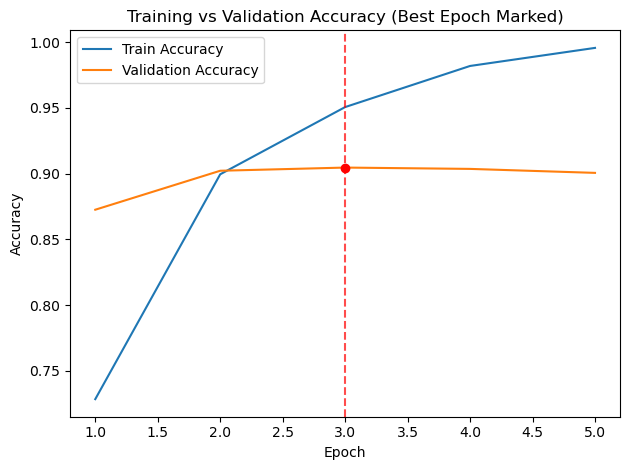

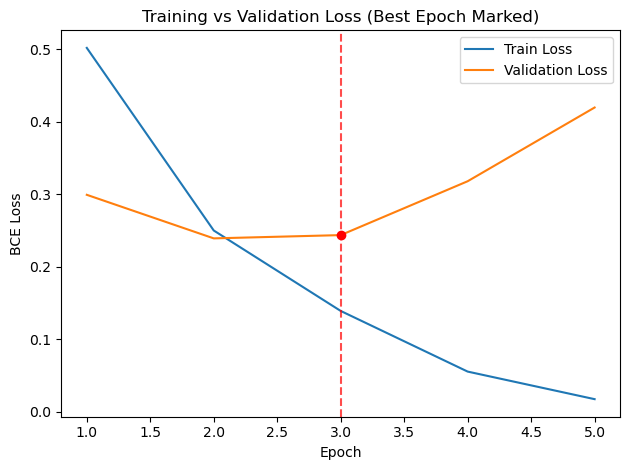


Chosen threshold on validation: th=0.49 (val F1=0.9071, val Acc=0.9054)

[Test] Best single snapshot (tuned threshold):
[[2195  275]
 [ 190 2298]]
              precision    recall  f1-score   support

           0     0.9203    0.8887    0.9042      2470
           1     0.8931    0.9236    0.9081      2488

    accuracy                         0.9062      4958
   macro avg     0.9067    0.9061    0.9062      4958
weighted avg     0.9067    0.9062    0.9062      4958


[Test] Top-2 ensemble (avg probs, tuned threshold):
[[2205  265]
 [ 195 2293]]
              precision    recall  f1-score   support

           0     0.9187    0.8927    0.9055      2470
           1     0.8964    0.9216    0.9088      2488

    accuracy                         0.9072      4958
   macro avg     0.9076    0.9072    0.9072      4958
weighted avg     0.9075    0.9072    0.9072      4958



In [60]:
# === IMDB BiLSTM (PyTorch, MPS-friendly) — retrain with history, early stopping, best-epoch plots, tuned threshold ===
import os, random, math, numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt

# ---------- Config (mirrors tuned setup) ----------
SEED = 42
MAX_LEN = 320
VOCAB_SIZE = 30000
EMBED_DIM  = 192
HIDDEN     = 128
DROPOUT    = 0.5
WEIGHT_DECAY = 1e-5
LR = 1e-3

BASE_BATCH   = 16          # VRAM-safe batch
ACCUM_STEPS  = 2           # effective batch = 32 via gradient accumulation
EPOCHS       = 10
PATIENCE     = 1           # quicker stop to avoid overfitting tails
WARMUP_EPOCHS = 1

NUM_WORKERS = 0            # macOS/MPS stability
PIN_MEMORY  = False

# ---------- Determinism ----------
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# ---------- Device ----------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ---------- Load arrays ----------
npz = np.load("artifacts/imdb_splits.npz")
Xtr, ytr = npz["X_train"], npz["y_train"]
Xva, yva = npz["X_val"],   npz["y_val"]
Xte, yte = npz["X_test"],  npz["y_test"]

# Trim to MAX_LEN
if Xtr.shape[1] > MAX_LEN:
    Xtr = Xtr[:, :MAX_LEN]; Xva = Xva[:, :MAX_LEN]; Xte = Xte[:, :MAX_LEN]

train_ds = TensorDataset(torch.tensor(Xtr, dtype=torch.long), torch.tensor(ytr, dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(Xva, dtype=torch.long), torch.tensor(yva, dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(Xte, dtype=torch.long), torch.tensor(yte, dtype=torch.float32))

def make_loader(ds, bs, shuffle=False):
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

train_loader = make_loader(train_ds, BASE_BATCH, shuffle=True)
val_loader   = make_loader(val_ds,   BASE_BATCH)
test_loader  = make_loader(test_ds,  BASE_BATCH)

# ---------- Model ----------
class BiLSTM(nn.Module):
    def __init__(self, vocab, embed, hidden, dropout=0.5):
        super().__init__()
        self.emb  = nn.Embedding(vocab, embed, padding_idx=0)
        self.lstm = nn.LSTM(embed, hidden, batch_first=True, bidirectional=True)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc1  = nn.Linear(hidden*2, 128)
        self.drop = nn.Dropout(dropout)
        self.out  = nn.Linear(128, 1)
    def forward(self, x):
        x = self.emb(x)               # (B,L,E)
        x, _ = self.lstm(x)           # (B,L,2H)
        x = self.pool(x.transpose(1,2)).squeeze(-1)  # (B,2H)
        x = torch.relu(self.fc1(x))
        x = self.drop(x)
        return torch.sigmoid(self.out(x)).squeeze(-1)

model  = BiLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN, DROPOUT).to(device)
opt    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
lossfn = nn.BCELoss()

# Cosine LR with warmup (per optimizer step, accounts for accumulation)
steps_per_epoch = math.ceil(len(train_loader) / ACCUM_STEPS)
total_steps  = EPOCHS * steps_per_epoch
warmup_steps = max(1, WARMUP_EPOCHS * steps_per_epoch)
def lr_lambda(step):
    if step < warmup_steps:
        return float(step+1)/float(warmup_steps)
    progress = (step - warmup_steps)/max(1,(total_steps - warmup_steps))
    return 0.5*(1.0 + math.cos(math.pi*progress))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda)

# ---------- Helpers ----------
def collect_probs(m, loader):
    m.eval(); out=[]
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            out += m(xb).cpu().numpy().ravel().tolist()
    return np.array(out)

def eval_metrics(m, loader, y_true, thr=0.5):
    probs = collect_probs(m, loader)
    preds = (probs >= thr).astype(int)
    return f1_score(y_true, preds), (preds == y_true).mean(), probs, preds

def compute_val_loss(m, loader, lossfn):
    m.eval(); tot=n=0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            p = m(xb)
            loss = lossfn(p, yb)
            tot += loss.item()*xb.size(0)
            n   += xb.size(0)
    return tot/max(1,n)

# ---------- History + snapshots ----------
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}
top_k = 2
snapshots = []   # list of {'f1','acc','state'}
bad = 0
best_f1_seen = -1.0

# ---------- Train ----------
opt.zero_grad(set_to_none=True)
global_step = 0

for epoch in range(1, EPOCHS+1):
    model.train()
    run_loss_unscaled = 0.0
    run_correct = 0
    run_n = 0

    for i, (xb, yb) in enumerate(train_loader, 1):
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss_unscaled = lossfn(pred, yb)
        (loss_unscaled / ACCUM_STEPS).backward()

        # epoch stats (unscaled)
        run_loss_unscaled += loss_unscaled.item() * xb.size(0)
        run_correct       += ((pred.detach() >= 0.5).float() == yb).sum().item()
        run_n             += xb.size(0)

        if i % ACCUM_STEPS == 0:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step(); opt.zero_grad(set_to_none=True)
            sched.step()
            global_step += 1

    # Validation @ 0.5
    val_f1, val_acc, _, _ = eval_metrics(model, val_loader, yva, thr=0.5)
    val_loss = compute_val_loss(model, val_loader, lossfn)

    # Log history
    history["train_loss"].append(run_loss_unscaled / max(1, run_n))
    history["train_acc"].append(run_correct / max(1, run_n))
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d} | train_loss {history['train_loss'][-1]:.4f} | "
          f"train_acc {history['train_acc'][-1]:.4f} | val_loss {val_loss:.4f} | "
          f"val_acc {val_acc:.4f} | val_f1 {val_f1:.4f}")

    # Save snapshot & early stopping (by val F1, tie-break acc)
    snap = {'f1': val_f1, 'acc': val_acc,
            'state': {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}}
    snapshots.append(snap)
    snapshots = sorted(snapshots, key=lambda s: (s['f1'], s['acc']), reverse=True)[:top_k]

    improved = val_f1 > best_f1_seen + 1e-6
    if improved:
        best_f1_seen = val_f1; bad = 0
    else:
        bad += 1
        if bad > PATIENCE:
            print("Early stopping.")
            break

    if device.type == "mps":
        torch.mps.empty_cache()

# ---------- Pick best epoch by val F1, plot curves with marker ----------
best_idx = int(np.argmax(history["val_f1"]))
best_epoch = best_idx + 1
print(f"\nBest epoch by validation F1: {best_epoch} "
      f"(val_acc={history['val_acc'][best_idx]:.4f}, val_f1={history['val_f1'][best_idx]:.4f})")

epochs_range = range(1, len(history["val_acc"]) + 1)

plt.figure()
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"],   label="Validation Accuracy")
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.7)
plt.scatter([best_epoch], [history["val_acc"][best_idx]], color="red", zorder=5)
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Training vs Validation Accuracy (Best Epoch Marked)")
plt.legend(); plt.tight_layout(); plt.show()

plt.figure()
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"],   label="Validation Loss")
plt.axvline(best_epoch, color="red", linestyle="--", alpha=0.7)
plt.scatter([best_epoch], [history["val_loss"][best_idx]], color="red", zorder=5)
plt.xlabel("Epoch"); plt.ylabel("BCE Loss"); plt.title("Training vs Validation Loss (Best Epoch Marked)")
plt.legend(); plt.tight_layout(); plt.show()

# ---------- Threshold tuning on validation using BEST snapshot ----------
best_single = snapshots[0]  # already sorted by (F1, acc)
model.load_state_dict(best_single['state'])

val_probs = collect_probs(model, val_loader)
ths = np.linspace(0.3, 0.7, 41)
f1s = [f1_score(yva, (val_probs >= t).astype(int)) for t in ths]
accs = [accuracy_score(yva, (val_probs >= t).astype(int)) for t in ths]
best_thr = float(ths[int(np.argmax(f1s))])
print(f"\nChosen threshold on validation: th={best_thr:.2f} (val F1={max(f1s):.4f}, val Acc={accs[int(np.argmax(f1s))]:.4f})")

# ---------- Final TEST: best single (tuned threshold) ----------
test_probs = collect_probs(model, test_loader)
test_preds = (test_probs >= best_thr).astype(int)
print("\n[Test] Best single snapshot (tuned threshold):")
print(confusion_matrix(yte, test_preds))
print(classification_report(yte, test_preds, digits=4))

# ---------- Final TEST: top-2 ensemble (avg probs, tuned threshold) ----------
probs_list = []
for s in snapshots:
    model.load_state_dict(s['state'])
    probs_list.append(collect_probs(model, test_loader))
ens_probs = np.mean(np.vstack(probs_list), axis=0)
ens_preds = (ens_probs >= best_thr).astype(int)   # (optionally re-tune thr on val ensemble)
print("\n[Test] Top-2 ensemble (avg probs, tuned threshold):")
print(confusion_matrix(yte, ens_preds))
print(classification_report(yte, ens_preds, digits=4))


In [62]:
# === Sanity check: Show a few real predictions ===
import random

# Pick 5 random indices from the test set
idxs = random.sample(range(len(Xte)), 5)

# Get probs & preds from trained (best snapshot) model
test_probs = collect_probs(model, test_loader)
test_preds = (test_probs >= best_thr).astype(int)

for i in idxs:
    review_tokens = Xte[i][:50]  # first 50 tokens (not decoded yet, just to see shape)
    true_label = int(yte[i])
    pred_label = int(test_preds[i])
    prob = test_probs[i]

    print("Review snippet:", review_tokens)
    print(f"True: {true_label} | Pred: {pred_label} | Prob: {prob:.3f}\n")


Review snippet: [  375     2  7009    47    68   114    78     4    19   447   686  1159
  8588  3579    96   109   388   348     8     2   170   303  4613    38
    43    22  1513     1  5435    62 25455  8588   112     6     4   688
   284   299   372   282     8   109   155     2   283   110     7  3579
 28009     4]
True: 1 | Pred: 1 | Prob: 0.964

Review snippet: [  10   66   25    6  134   11   13  217    4  526    5 1861   51   10
  425    6   65   58 8698    3    9  133    7    9    7   53   53  502
    6    2  271    2   97    9    7  759    3    2 1851   71   39   30
  322   46   10   25    6  376   11   15]
True: 1 | Pred: 1 | Prob: 1.000

Review snippet: [ 5466    50  8722    17    30     2   151   751    81  1126   516 13963
    29    24   119   732     5   331  1263     3   514     3   243     2
   119     5     2 11192  7032   208  1004  3558   291  1785  8191     3
    29    24 21588   119     4 21431     6     2  1613   130   208   376
     6   305]
True: 1 | Pred: 1 |

In [66]:
# === Model B: TextCNN (fast, M2/MPS-friendly, no tuning) ===
import time, numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix

# ----------------- Config (speed-focused) -----------------
SEED = 42
MAX_LEN = 256          # shorter sequences -> faster
VOCAB_SIZE = 30000
EMBED_DIM  = 192
CHANNELS   = 96        # was 128; 96 is faster with minimal impact
FILTER_SIZES = [3,4,5]
DROPOUT    = 0.5

LR         = 1e-3
BATCH_SIZE = 64        # balance speed/VRAM
EPOCHS     = 5         # fixed small number (no tuning)
PATIENCE   = 2         # simple early stop on val acc

# ----------------- Repro & Device -----------------
torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ----------------- Data -----------------
npz = np.load("artifacts/imdb_splits.npz")
Xtr, ytr = npz["X_train"], npz["y_train"]
Xva, yva = npz["X_val"],   npz["y_val"]
Xte, yte = npz["X_test"],  npz["y_test"]

# Trim length for speed
if Xtr.shape[1] > MAX_LEN:
    Xtr = Xtr[:, :MAX_LEN]; Xva = Xva[:, :MAX_LEN]; Xte = Xte[:, :MAX_LEN]

train_ds = TensorDataset(torch.tensor(Xtr, dtype=torch.long),
                         torch.tensor(ytr, dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(Xva, dtype=torch.long),
                         torch.tensor(yva, dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(Xte, dtype=torch.long),
                         torch.tensor(yte, dtype=torch.float32))

def make_loader(ds, bs, shuffle=False):
    # num_workers=0 & pin_memory=False are stable on macOS/MPS
    return DataLoader(ds, batch_size=bs, shuffle=shuffle, num_workers=0, pin_memory=False)

train_loader = make_loader(train_ds, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(val_ds,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_ds,  BATCH_SIZE, shuffle=False)

# ----------------- Model: TextCNN -----------------
class TextCNN(nn.Module):
    def __init__(self, vocab, embed_dim, channels, filter_sizes, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=channels, kernel_size=k)
            for k in filter_sizes
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(channels * len(filter_sizes), 128)
        self.out  = nn.Linear(128, 1)

    def forward(self, x):
        x = self.emb(x)               # (B, L, E)
        x = x.transpose(1, 2)         # (B, E, L) for Conv1d
        feats = []
        for conv in self.convs:
            h = torch.relu(conv(x))                       # (B, C, L-k+1)
            h = torch.max_pool1d(h, kernel_size=h.size(2)).squeeze(2)  # (B, C)
            feats.append(h)
        z = torch.cat(feats, dim=1)                       # (B, C * len(filters))
        z = torch.relu(self.fc(self.drop(z)))
        return torch.sigmoid(self.out(z)).squeeze(-1)     # (B,)

model = TextCNN(VOCAB_SIZE, EMBED_DIM, CHANNELS, FILTER_SIZES, DROPOUT).to(device)
opt    = torch.optim.Adam(model.parameters(), lr=LR)
lossfn = nn.BCELoss()

# ----------------- Train (with simple early stopping on val acc) -----------------
best_val, bad, best_state = 0.0, 0, None
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    # train
    model.train(); total=correct=loss_sum=0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = lossfn(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item() * xb.size(0)
        correct  += ((pred >= 0.5).float() == yb).sum().item()
        total    += xb.size(0)
    tr_acc = correct/total

    # validate
    model.eval(); total=correct=0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            correct += ((pred >= 0.5).float() == yb).sum().item()
            total   += xb.size(0)
    va_acc = correct/total

    dt = time.time() - t0
    print(f"Epoch {epoch}: train acc {tr_acc:.4f} | val acc {va_acc:.4f} | time {dt:.1f}s")

    if va_acc > best_val:
        best_val = va_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        bad = 0
    else:
        bad += 1
        if bad > PATIENCE:
            print("Early stopping.")
            break
    if device.type == "mps":
        torch.mps.empty_cache()

# ----------------- Test evaluation (threshold = 0.5) -----------------
if best_state is not None:
    model.load_state_dict(best_state)
model.eval()
all_preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        all_preds += (model(xb).cpu().numpy().ravel() >= 0.5).tolist()
all_preds = np.array(all_preds, dtype=int)

print("\nConfusion Matrix (test):")
print(confusion_matrix(yte, all_preds))
print("\nClassification Report (test):")
print(classification_report(yte, all_preds, digits=4))


Using device: mps
Epoch 1: train acc 0.7034 | val acc 0.8253 | time 26.5s
Epoch 2: train acc 0.8205 | val acc 0.8669 | time 26.2s
Epoch 3: train acc 0.8641 | val acc 0.8766 | time 26.4s
Epoch 4: train acc 0.8990 | val acc 0.8844 | time 26.4s
Epoch 5: train acc 0.9271 | val acc 0.8943 | time 26.4s

Confusion Matrix (test):
[[2175  295]
 [ 273 2215]]

Classification Report (test):
              precision    recall  f1-score   support

           0     0.8885    0.8806    0.8845      2470
           1     0.8825    0.8903    0.8864      2488

    accuracy                         0.8854      4958
   macro avg     0.8855    0.8854    0.8854      4958
weighted avg     0.8855    0.8854    0.8854      4958



Using device: mps

=== Config: filters=[3, 4, 5] | channels=64 | dropout=0.3 ===
Epoch 1: train acc=0.7306 | val acc=0.8009 | val F1=0.8266
Epoch 2: train acc=0.8393 | val acc=0.8723 | val F1=0.8716
Epoch 3: train acc=0.8841 | val acc=0.8721 | val F1=0.8806

=== Config: filters=[3, 4, 5] | channels=64 | dropout=0.5 ===
Epoch 1: train acc=0.6866 | val acc=0.8122 | val F1=0.8066
Epoch 2: train acc=0.8056 | val acc=0.8540 | val F1=0.8505
Epoch 3: train acc=0.8566 | val acc=0.8737 | val F1=0.8776

=== Config: filters=[3, 4, 5] | channels=128 | dropout=0.3 ===
Epoch 1: train acc=0.7484 | val acc=0.8399 | val F1=0.8477
Epoch 2: train acc=0.8602 | val acc=0.8679 | val F1=0.8757
Epoch 3: train acc=0.8955 | val acc=0.8854 | val F1=0.8825

=== Config: filters=[3, 4, 5] | channels=128 | dropout=0.5 ===
Epoch 1: train acc=0.7102 | val acc=0.8245 | val F1=0.8357
Epoch 2: train acc=0.8252 | val acc=0.8540 | val F1=0.8643
Epoch 3: train acc=0.8745 | val acc=0.8812 | val F1=0.8836

=== Config: filters

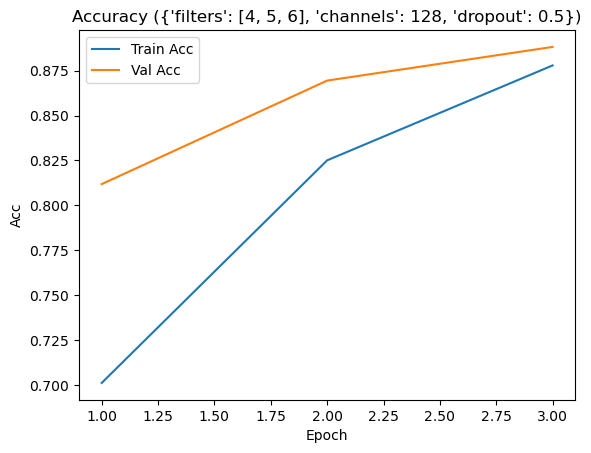

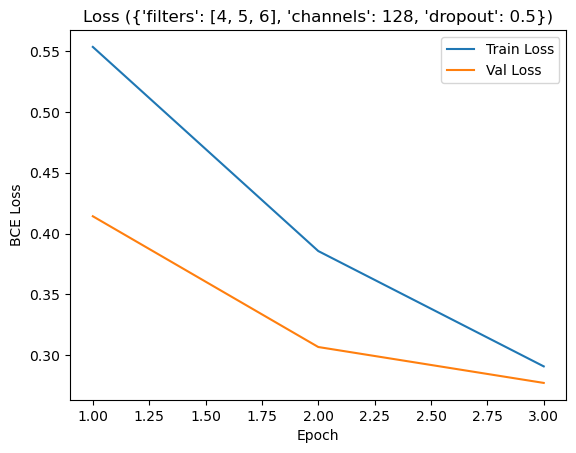

In [68]:
# === CNN-Specific Hyperparameter Sweep for TextCNN (with history logging) ===
import time, numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

# ----------------- Base config -----------------
SEED = 42
MAX_LEN = 256
VOCAB_SIZE = 30000
EMBED_DIM  = 192
LR         = 1e-3
BATCH_SIZE = 64
EPOCHS_SWEEP = 3   # short sweep per config

torch.manual_seed(SEED); np.random.seed(SEED)
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# ----------------- Data -----------------
npz = np.load("artifacts/imdb_splits.npz")
Xtr, ytr = npz["X_train"], npz["y_train"]
Xva, yva = npz["X_val"],   npz["y_val"]

if Xtr.shape[1] > MAX_LEN:
    Xtr = Xtr[:, :MAX_LEN]; Xva = Xva[:, :MAX_LEN]

train_ds = TensorDataset(torch.tensor(Xtr, dtype=torch.long),
                         torch.tensor(ytr, dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(Xva, dtype=torch.long),
                         torch.tensor(yva, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# ----------------- Model -----------------
class TextCNN(nn.Module):
    def __init__(self, vocab, embed_dim, channels, filter_sizes, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=channels, kernel_size=k)
            for k in filter_sizes
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(channels * len(filter_sizes), 128)
        self.out  = nn.Linear(128, 1)

    def forward(self, x):
        x = self.emb(x)               # (B, L, E)
        x = x.transpose(1, 2)         # (B, E, L)
        feats = []
        for conv in self.convs:
            h = torch.relu(conv(x))
            h = torch.max_pool1d(h, h.size(2)).squeeze(2)
            feats.append(h)
        z = torch.cat(feats, dim=1)
        z = torch.relu(self.fc(self.drop(z)))
        return torch.sigmoid(self.out(z)).squeeze(-1)

# ----------------- Sweep configs -----------------
configs = [
    {"filters": [3,4,5], "channels": 64, "dropout": 0.3},
    {"filters": [3,4,5], "channels": 64, "dropout": 0.5},
    {"filters": [3,4,5], "channels": 128, "dropout": 0.3},
    {"filters": [3,4,5], "channels": 128, "dropout": 0.5},
    {"filters": [2,3,4], "channels": 128, "dropout": 0.5},
    {"filters": [4,5,6], "channels": 128, "dropout": 0.5},
]

results = []

# ----------------- Training function -----------------
def train_config(cfg):
    model = TextCNN(VOCAB_SIZE, EMBED_DIM, cfg["channels"], cfg["filters"], cfg["dropout"]).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    lossfn = nn.BCELoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_f1": []}

    for epoch in range(1, EPOCHS_SWEEP+1):
        # Train
        model.train(); total=correct=loss_sum=0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = lossfn(pred, yb)
            opt.zero_grad(); loss.backward(); opt.step()
            loss_sum += loss.item()*xb.size(0)
            correct  += ((pred >= 0.5).float() == yb).sum().item()
            total    += xb.size(0)
        train_loss = loss_sum/total; train_acc = correct/total

        # Val
        model.eval(); preds_all=[]; y_all=[]; val_loss_sum=0; val_total=0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb)
                val_loss_sum += lossfn(out, yb).item()*xb.size(0)
                val_total    += xb.size(0)
                preds_all.extend((out>=0.5).float().cpu().numpy())
                y_all.extend(yb.cpu().numpy())
        val_loss = val_loss_sum/val_total
        val_acc  = accuracy_score(y_all, preds_all)
        val_f1   = f1_score(y_all, preds_all)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(f"Epoch {epoch}: train acc={train_acc:.4f} | val acc={val_acc:.4f} | val F1={val_f1:.4f}")

    return max(history["val_f1"]), history

# ----------------- Run sweep -----------------
for cfg in configs:
    print(f"\n=== Config: filters={cfg['filters']} | channels={cfg['channels']} | dropout={cfg['dropout']} ===")
    best_f1, hist = train_config(cfg)
    results.append((cfg, best_f1, hist))

# ----------------- Results -----------------
results = sorted(results, key=lambda x: x[1], reverse=True)
print("\n=== Sweep Results (sorted by val F1) ===")
for cfg, score, _ in results:
    print(f"{cfg} -> val F1={score:.4f}")

# ----------------- Plot top config -----------------
best_cfg, _, best_hist = results[0]
epochs = range(1, len(best_hist["val_acc"])+1)

plt.figure()
plt.plot(epochs, best_hist["train_acc"], label="Train Acc")
plt.plot(epochs, best_hist["val_acc"],   label="Val Acc")
plt.legend(); plt.title(f"Accuracy ({best_cfg})"); plt.xlabel("Epoch"); plt.ylabel("Acc")
plt.show()

plt.figure()
plt.plot(epochs, best_hist["train_loss"], label="Train Loss")
plt.plot(epochs, best_hist["val_loss"],   label="Val Loss")
plt.legend(); plt.title(f"Loss ({best_cfg})"); plt.xlabel("Epoch"); plt.ylabel("BCE Loss")
plt.show()


Using device: mps
Epoch 1: train acc=0.7231 | val acc=0.8469 | val F1=0.8431
Epoch 2: train acc=0.8372 | val acc=0.8830 | val F1=0.8852
Epoch 3: train acc=0.8851 | val acc=0.8961 | val F1=0.8975
Epoch 4: train acc=0.9182 | val acc=0.8899 | val F1=0.8862
Epoch 5: train acc=0.9424 | val acc=0.8971 | val F1=0.8992
Epoch 6: train acc=0.9611 | val acc=0.8931 | val F1=0.8941
Epoch 7: train acc=0.9742 | val acc=0.8955 | val F1=0.8957
Epoch 8: train acc=0.9821 | val acc=0.8933 | val F1=0.8920
Early stopping.
Chosen threshold: 0.54 | Val F1=0.9010

Confusion Matrix (test):
[[2186  284]
 [ 220 2268]]

Classification Report (test):
              precision    recall  f1-score   support

           0     0.9086    0.8850    0.8966      2470
           1     0.8887    0.9116    0.9000      2488

    accuracy                         0.8983      4958
   macro avg     0.8986    0.8983    0.8983      4958
weighted avg     0.8986    0.8983    0.8983      4958



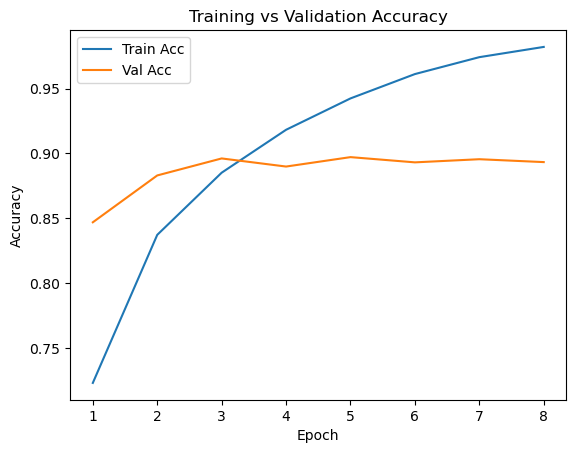

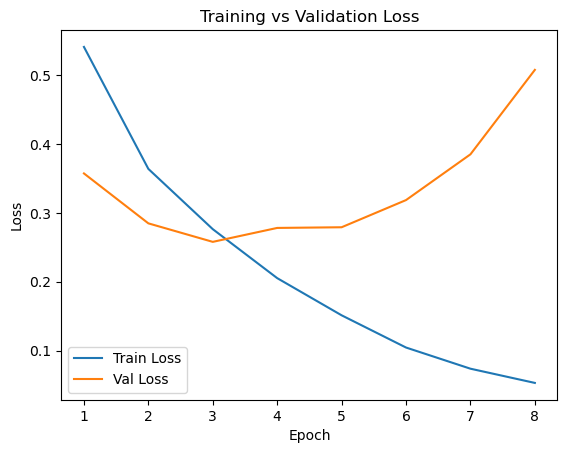

In [70]:
# === Final CNN Model B with history logging and tuning ===
import numpy as np, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt

# -------- Load prepared arrays --------
npz = np.load("artifacts/imdb_splits.npz")
Xtr, ytr = npz["X_train"], npz["y_train"]
Xva, yva = npz["X_val"],   npz["y_val"]
Xte, yte = npz["X_test"],  npz["y_test"]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

# -------- Datasets & Loaders --------
train_ds = TensorDataset(torch.tensor(Xtr, dtype=torch.long),
                         torch.tensor(ytr, dtype=torch.float32))
val_ds   = TensorDataset(torch.tensor(Xva, dtype=torch.long),
                         torch.tensor(yva, dtype=torch.float32))
test_ds  = TensorDataset(torch.tensor(Xte, dtype=torch.long),
                         torch.tensor(yte, dtype=torch.float32))

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64)
test_loader  = DataLoader(test_ds, batch_size=64)

# -------- Model (CNN) --------
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, dropout=0.5):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(in_channels=embed_dim, out_channels=num_filters, kernel_size=fs)
            for fs in filter_sizes
        ])
        self.drop = nn.Dropout(dropout)
        self.fc   = nn.Linear(num_filters * len(filter_sizes), 1)

    def forward(self, x):
        x = self.emb(x).transpose(1, 2)   # (B, E, L)
        convs = [torch.relu(conv(x)) for conv in self.convs]
        pools = [torch.max(c, dim=2)[0] for c in convs]
        x = torch.cat(pools, dim=1)
        x = self.drop(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)

# Best config from sweep
VOCAB_SIZE, EMBED_DIM = 30000, 192
FILTERS, CHANNELS, DROPOUT = [4,5,6], 128, 0.5

model = TextCNN(VOCAB_SIZE, EMBED_DIM, CHANNELS, FILTERS, DROPOUT).to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.BCELoss()

# -------- Helpers --------
def eval_model(model, loader, y_true, thr=0.5):
    model.eval(); preds=[]; probs=[]
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            pr = model(xb).cpu().numpy().ravel()
            probs.extend(pr)
            preds.extend((pr >= thr).astype(int))
    return np.array(probs), np.array(preds)

# -------- Training --------
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_f1, bad, patience = -1, 0, 2
best_state = None

for epoch in range(10):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pr = model(xb)
        loss = loss_fn(pr, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        loss_sum += loss.item()*xb.size(0)
        correct  += ((pr>=0.5).float()==yb).sum().item()
        total    += xb.size(0)
    train_loss, train_acc = loss_sum/total, correct/total

    # Validation
    probs, preds = eval_model(model, val_loader, yva, thr=0.5)
    val_loss = loss_fn(torch.tensor(probs), torch.tensor(yva, dtype=torch.float32)).item()
    val_acc  = (preds==yva).mean()
    val_f1   = f1_score(yva, preds)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: train acc={train_acc:.4f} | val acc={val_acc:.4f} | val F1={val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1, bad = val_f1, 0
        best_state = {k:v.cpu().clone() for k,v in model.state_dict().items()}
    else:
        bad += 1
        if bad > patience:
            print("Early stopping."); break

# -------- Reload best --------
model.load_state_dict(best_state)

# -------- Threshold tuning --------
probs, _ = eval_model(model, val_loader, yva, thr=0.5)
best_thr, best_valf1 = 0.5, -1
for th in np.linspace(0.3,0.7,41):
    f1 = f1_score(yva, (probs>=th).astype(int))
    if f1 > best_valf1: best_valf1, best_thr = f1, th
print(f"Chosen threshold: {best_thr:.2f} | Val F1={best_valf1:.4f}")

# -------- Final Test --------
probs, preds = eval_model(model, test_loader, yte, thr=best_thr)
print("\nConfusion Matrix (test):")
print(confusion_matrix(yte, preds))
print("\nClassification Report (test):")
print(classification_report(yte, preds, digits=4))

# -------- Plots --------
epochs = range(1, len(history["train_acc"])+1)
plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy"); plt.legend(); plt.show()

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training vs Validation Loss"); plt.legend(); plt.show()


In [86]:
# --- Reliable layer-by-layer summaries for PyTorch models with Embedding ---

from torchinfo import summary
import torch

# Choose the same vocab/seq length you trained with
VOCAB_SIZE = 30000
SEQ_LEN    = 320   
BATCH      = 4     

# Prefer MPS; fall back to CPU if needed
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Summarizing on:", device)

def summarize_model(model, name="Model"):
    """Create a correct Long dummy input and run torchinfo.summary safely."""
    model = model.to(device).eval()
    # Long token IDs for Embedding
    x = torch.randint(0, VOCAB_SIZE, (BATCH, SEQ_LEN), dtype=torch.long, device=device)
    try:
        print(f"\n=== {name} ===")
        summary(
            model,
            input_data=x,                              # <- LongTensor, not input_size
            col_names=["input_size","output_size","num_params","kernel_size"],
            depth=3,
            verbose=1
        )
    except Exception as e:
        # Some MPS stacks can be picky; CPU as a fallback
        print(f"[Info] {name}: retrying on CPU due to: {e}")
        model_cpu = model.to("cpu")
        x_cpu = x.to("cpu")
        summary(
            model_cpu,
            input_data=x_cpu,
            col_names=["input_size","output_size","num_params","kernel_size"],
            depth=3,
            verbose=1
        )


summarize_model(model_a, "BiLSTM (Model A)")
#summarize_model(model_b, "TextCNN (Model B)")


# For TextCNN: TextCNN(vocab_size, embed_dim, num_filters, filter_sizes, dropout=0.5)
model_b = TextCNN( VOCAB_SIZE, 192, 128, [4,5,6], 0.5 )
summarize_model(model_b, "TextCNN (Model B)")


Summarizing on: mps

=== BiLSTM (Model A) ===
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
BiLSTM                                   [4, 320]                  [4]                       --                        --
├─Embedding: 1-1                         [4, 320]                  [4, 320, 192]             5,760,000                 --
├─LSTM: 1-2                              [4, 320, 192]             [4, 320, 256]             329,728                   --
├─AdaptiveMaxPool1d: 1-3                 [4, 256, 320]             [4, 256, 1]               --                        --
├─Linear: 1-4                            [4, 256]                  [4, 128]                  32,896                    --
├─Dropout: 1-5                           [4, 128]                  [4, 128]                  --                        --
├─Linear: 1-6                            [4, 128]                  [4, 1]                 